# Comparing PMoAs for Flupyradifurone based on local optimization

## Notebook setup

In [1]:
using DrWatson
@quickactivate "."

In [2]:
using Revise

const SAVETAG_LARVALFIT = "input/Discoglossus_larvae" # directory from which larval/metamorph parameters are loaded
const SAVETAG_JUVENILEFIT = "input/Discoglossus_juveniles" # directory from which juvenile/adult parameters are loaded
const SAVETAG_TKTD = "Discoglossus_Flupyradifurone"
const SAVETAG = "Discoglossus_Flupyradifurone"

using Revise

includet(scriptsdir("ModelFitting_Discoglossus_Flupyradifurone.jl")) 

## Running simulations for alternative PMoAs

In [9]:
# run simulations for alternative PMoAs
savedir = joinpath("Discoglossus_Flupyradifurone_2025-06-23_numtadpoles")

@suppress begin
    global fG = setup_modelfit("G")
    global p_opt_G = CSV.read(datadir("sims", savedir, "$(SAVETAG_TKTD)_G", "posterior_summary.csv"), DataFrame).best_fit
    global sim_opt_G = [fG.simulator(p_opt_G) for _ in 1:100]

    global fKAP = setup_modelfit("KAP")
    global p_opt_KAP = CSV.read(datadir("sims", savedir, "$(SAVETAG_TKTD)_KAP", "posterior_summary.csv"), DataFrame).best_fit
    global sim_opt_KAP = [fKAP.simulator(p_opt_KAP) for _ in 1:100];
end;

## Visual inspection

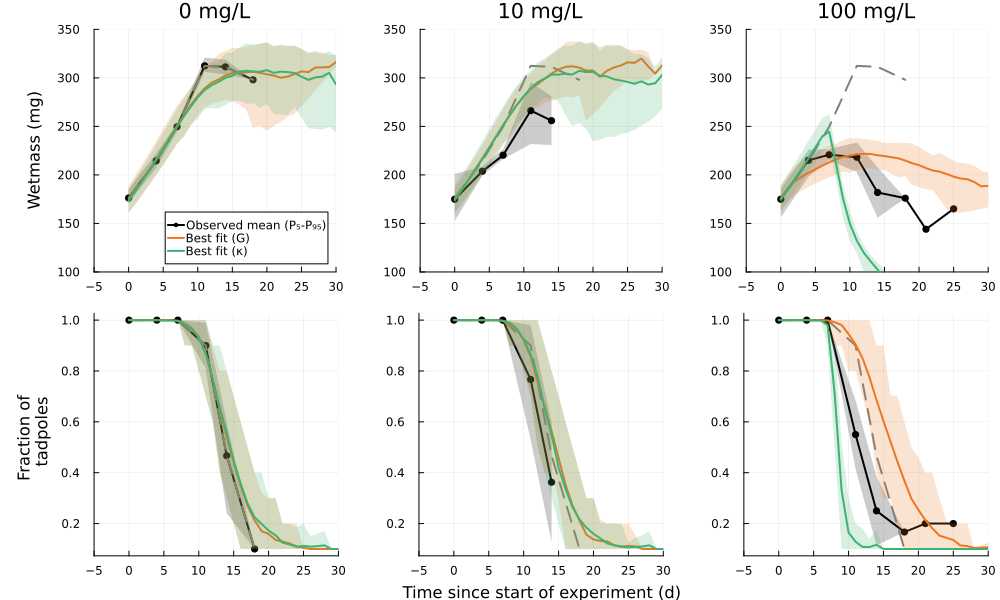

In [13]:
f = fG;
plt = plot_data()
plot_sims!(plt, sim_opt_G, label = "Best fit (G)", color = :chocolate2)
#plot_sims!(plt, sim_opt_M, label = "Best fit (M)", color = :steelblue)
#plot_sims!(plt, sim_opt_A, label = "Best fit (A)", color = :magenta)
plot_sims!(plt, sim_opt_KAP, label = "Best fit (κ)", color = :mediumseagreen)
#plot!(subplot = 1, xlim = (0,20))
#plot!(subplot = 2, xlim = (0,15))

savefig(plot(plt, dpi = 400), plotsdir("Discoglossus_Flupyradifurone_summaries_PMoA_comparison.png"))

plt

## Estimating model probabilities

In [19]:
[fG.loss(fG.data, sim) for sim in sim_opt_G] |> mean

0.053466224032869

In [21]:
"""
    accepted_from_tag(savetag::AbstractString)

Read accepted samples from a file.
"""
function accepted_from_tag(savetag::AbstractString)

    accepted = CSV.read(datadir("sims", savetag, "accepted.csv"), DataFrame)
    
    return accepted

end

accepted_G = accepted_from_tag(joinpath(savedir, "Discoglossus_Flupyradifurone_G")) 
accepted_KAP = accepted_from_tag(joinpath(savedir, "Discoglossus_Flupyradifurone_KAP"));

In [23]:
# calculate posterior probabilities based on rejection approach
using StatsBase
accepted_G[!,:model] .= "G"
accepted_KAP[!,:model] .= "KAP"

losses = vcat(
    accepted_G[:,[:model,:loss, :weight]],
    accepted_KAP[:,[:model,:loss, :weight]],
)

ϵ = quantile(losses.loss, 0.25)

losses_accepted = @subset(losses, :loss .<= ϵ)

probs = countmap(losses_accepted.model) |> OrderedDict |>
x -> DataFrame(model = x.keys, prob = x.vals ./ sum(values(x)))


Row,model,prob
,String,Float64
1,KAP,1.0


In [29]:
# calculate errors of posterior probabilities using bootstrapping

bootstrap_samplesize = Int(0.5*nrow(losses))
n_samples = 1000

bootstrap_probs_G = []
bootstrap_probs_KAP = []

for i in 1:n_samples

    bootstrap_idxs = sample(1:nrow(losses), bootstrap_samplesize)

    losses_i = losses[bootstrap_idxs,:] # get re-sampled subset of losses
    ϵ = quantile(losses_i.loss, 0.25) # compute the threshold for the bootstrap sample

    acc = @subset(losses_i, :loss .<= ϵ, :weight .> 0)

    probs_i = countmap(acc.model) |> OrderedDict |>
    x -> DataFrame(model = x.keys, prob = x.vals ./ sum(values(x)))

    for model in ["G", "KAP"] # add 0s for entirely rejected models
        if !(model in probs_i.model)
            append!(probs_i, DataFrame(
                model = model, 
                prob = 0.
            ))
        end
    end

    sort!(probs_i, :model)

    push!(bootstrap_probs_G, probs_i.prob[1])
    push!(bootstrap_probs_KAP, probs_i.prob[2])

end

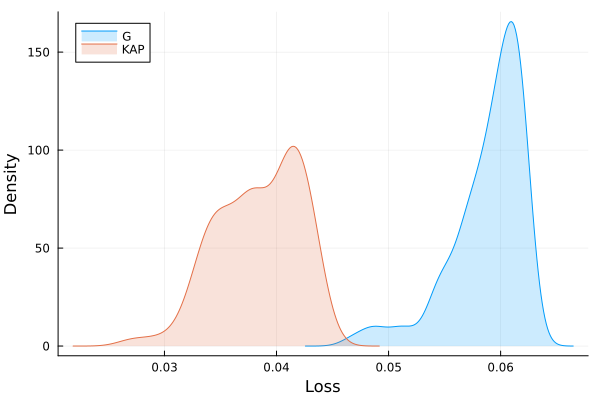

In [30]:
@df losses density(
    :loss, group = :model, 
    fill = true, fillalpha = .2, 
    xlabel = "Loss", ylabel = "Density"
    )

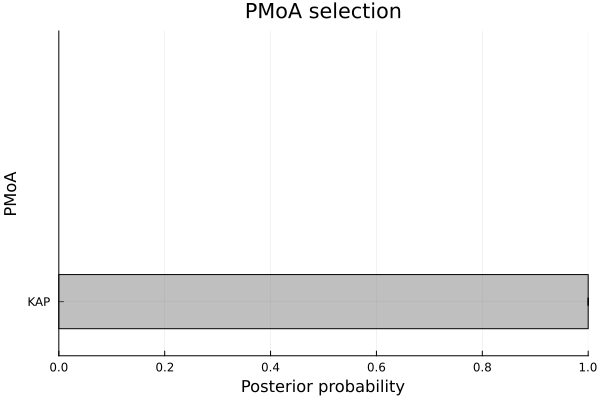

"c:\\Users\\shansul\\Documents\\AmphiDEBResearch-1\\WP02_TKTD\\plots\\Discoglossus_Flupyradiforne_summaries_PMoA_probabilities.png"

In [31]:
ci(x) = quantile(x, 0.75) - quantile(x, 0.25)

plt_probs = @df probs bar(
    :model, :prob, 
    permute = (:y, :x),
    yerrors = [ci(bootstrap_probs_A), ci(bootstrap_probs_M), ci(bootstrap_probs_G)], 
    xlim = (0,3), ylim = (0,1), 
    xlabel = "PMoA", ylabel = "Posterior probability",
    bar_width = 0.5, leg = false, 
    fillcolor = :gray, fillalpha = .5,
    title = "PMoA selection"
    )
display(plt_probs)
savefig(plot(plt_probs, dpi = 300), plotsdir("Discoglossus_Flupyradiforne_summaries_PMoA_probabilities.png"))

## Frequentist model selection

Since all alternative PMoAs have the same number of parameters, 
we perform frequentist model selection simply based on the loss values associated with the best fit of each PMoA. <br>

This indicates the lowest loss for $A$, followed very closesly by $M$. 

In [32]:
vcat(
    @subset(accepted_G, :loss .== minimum(:loss))[:,[:model,:loss]],
    @subset(accepted_KAP, :loss .== minimum(:loss))[:,[:model,:loss]],
) |> x-> @transform(x, :loss = round.(:loss, sigdigits = 2))

Row,model,loss
,String,Float64
1,G,0.047
2,KAP,0.027


## Conclusion 

- The output of both **frequentist** and **Bayesian** model selection is rather un-intuitive here. 
- Based on **visual inspection**, it seems quite clear that PMoA **G** is preferrable. 